# Tech Challenge - Fase 2

## Predição da Qualidade de Vinhos por meio de Machine Learning

### Bibliotecas Utilizadas

In [227]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from src import evaluate
from src import ml_models
from src import plots
from src import transforms

### Configuração dos Gráficos

In [228]:
plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11

### Carregando Base

In [229]:
df = pd.read_csv("../data/WineQT.csv", sep=",")
df["Qualidade"] = (df["quality"] >= 7).astype(int)
df = df.drop(columns=['Id','quality'])
df.rename(columns={
    "fixed acidity": "Acidez fixa",
    "volatile acidity": "Acidez volátil",
    "citric acid": "Ácido cítrico",
    "residual sugar": "Açúcar residual",
    "chlorides": "Cloretos",
    "free sulfur dioxide": "Dióxido de enxofre livre",
    "total sulfur dioxide": "Dióxido de enxofre total",
    "density": "Densidade",
    "pH": "pH",
    "sulphates": "Sulfatos",
    "alcohol": "Teor Alcoólico"
}, inplace=True)

### Inspeções Iniciais

In [230]:
print("Dimensões Base Original:", df.shape)

Dimensões Base Original: (1143, 12)


#### Primeiras linhas:

In [231]:
df.head()

,Acidez fixa,Acidez volátil,Ácido cítrico,Açúcar residual,Cloretos,Dióxido de enxofre livre,Dióxido de enxofre total,Densidade,pH,Sulfatos,Teor Alcoólico,Qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


#### Últimas linhas:

In [232]:
df.tail()

,Acidez fixa,Acidez volátil,Ácido cítrico,Açúcar residual,Cloretos,Dióxido de enxofre livre,Dióxido de enxofre total,Densidade,pH,Sulfatos,Teor Alcoólico,Qualidade
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,0
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


#### Tipos das variáveis:

In [233]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Acidez fixa               1143 non-null   float64
 1   Acidez volátil            1143 non-null   float64
 2   Ácido cítrico             1143 non-null   float64
 3   Açúcar residual           1143 non-null   float64
 4   Cloretos                  1143 non-null   float64
 5   Dióxido de enxofre livre  1143 non-null   float64
 6   Dióxido de enxofre total  1143 non-null   float64
 7   Densidade                 1143 non-null   float64
 8   pH                        1143 non-null   float64
 9   Sulfatos                  1143 non-null   float64
 10  Teor Alcoólico            1143 non-null   float64
 11  Qualidade                 1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


#### Estatísticas descritivas:

In [234]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Acidez fixa,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
Acidez volátil,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
Ácido cítrico,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
Açúcar residual,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
Cloretos,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
Dióxido de enxofre livre,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
Dióxido de enxofre total,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
Densidade,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
Sulfatos,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


#### Valores ausentes:

In [235]:
df.isnull().sum()

Acidez fixa                 0
Acidez volátil              0
Ácido cítrico               0
Açúcar residual             0
Cloretos                    0
Dióxido de enxofre livre    0
Dióxido de enxofre total    0
Densidade                   0
pH                          0
Sulfatos                    0
Teor Alcoólico              0
Qualidade                   0
dtype: int64

In [236]:
print("Valores duplicados:", df.duplicated().sum())

Valores duplicados: 125


## Análise Exploratória dos Dados (EDA)

### Distribuição da variável alvo - Qualidade:

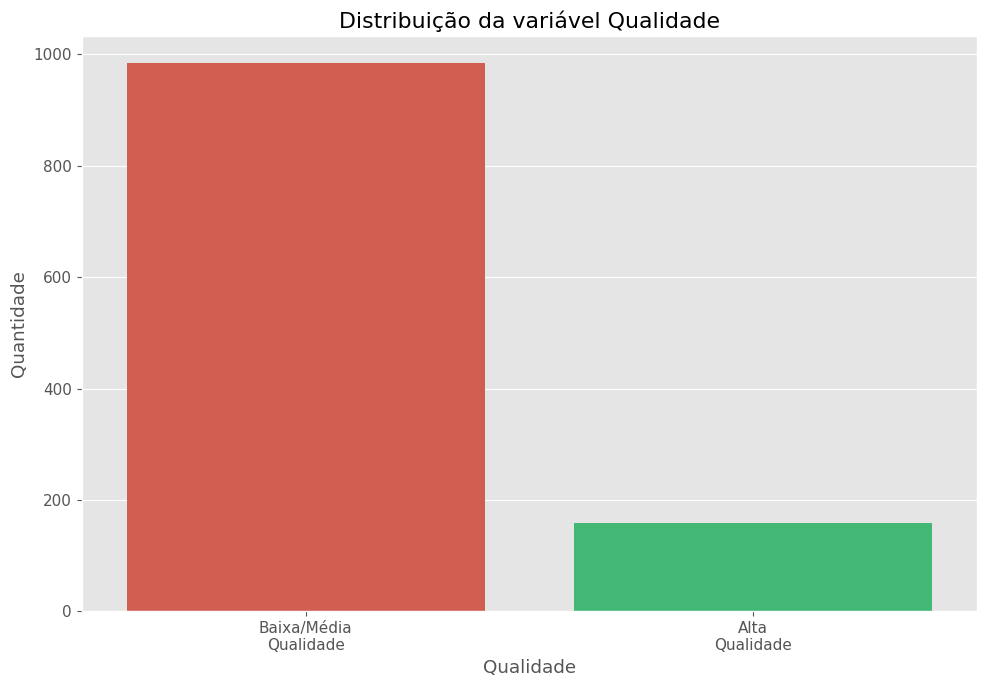

In [237]:
plots.plot_target_distribution(df, x_size=10, y_size=7, x_axis="Qualidade", hue="Qualidade", title="Distribuição da variável Qualidade", x_label="Qualidade", y_label="Quantidade", xticklabel=["Baixa/Média\nQualidade","Alta\nQualidade"])

### Distribuição das variáveis numéricas

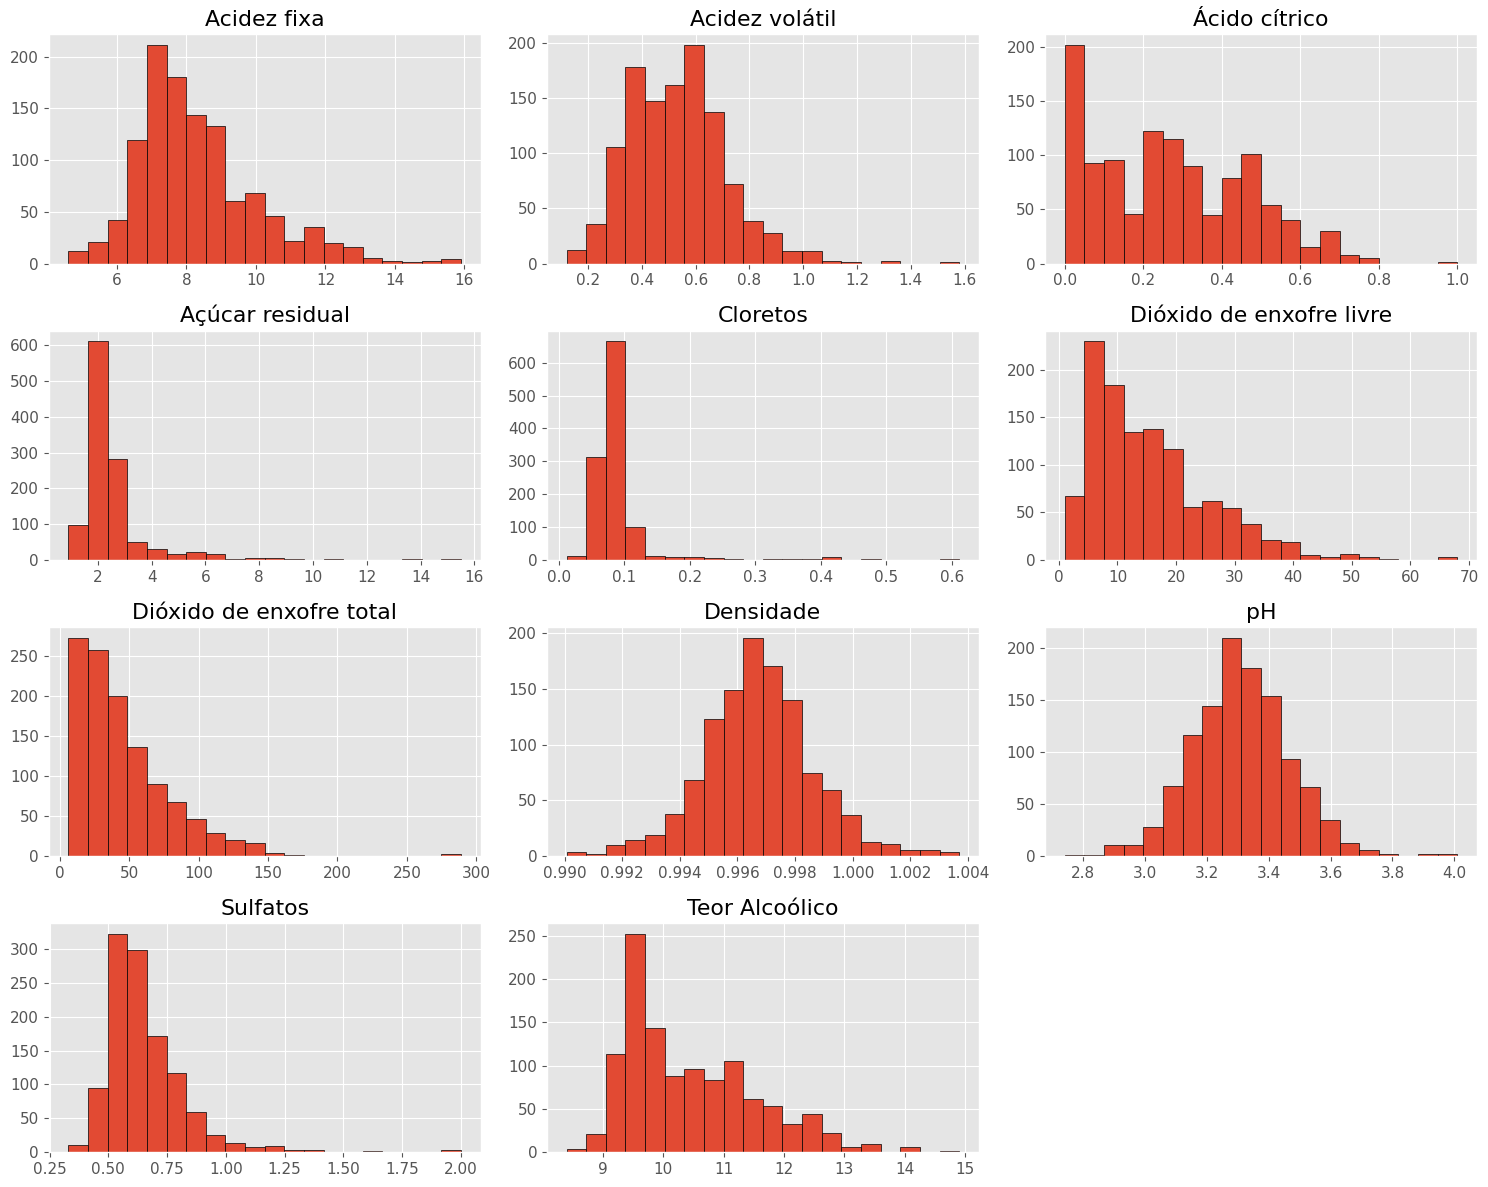

In [238]:
df_plot = df.drop(columns=["Qualidade"])

plots.plot_histograms(df_plot)

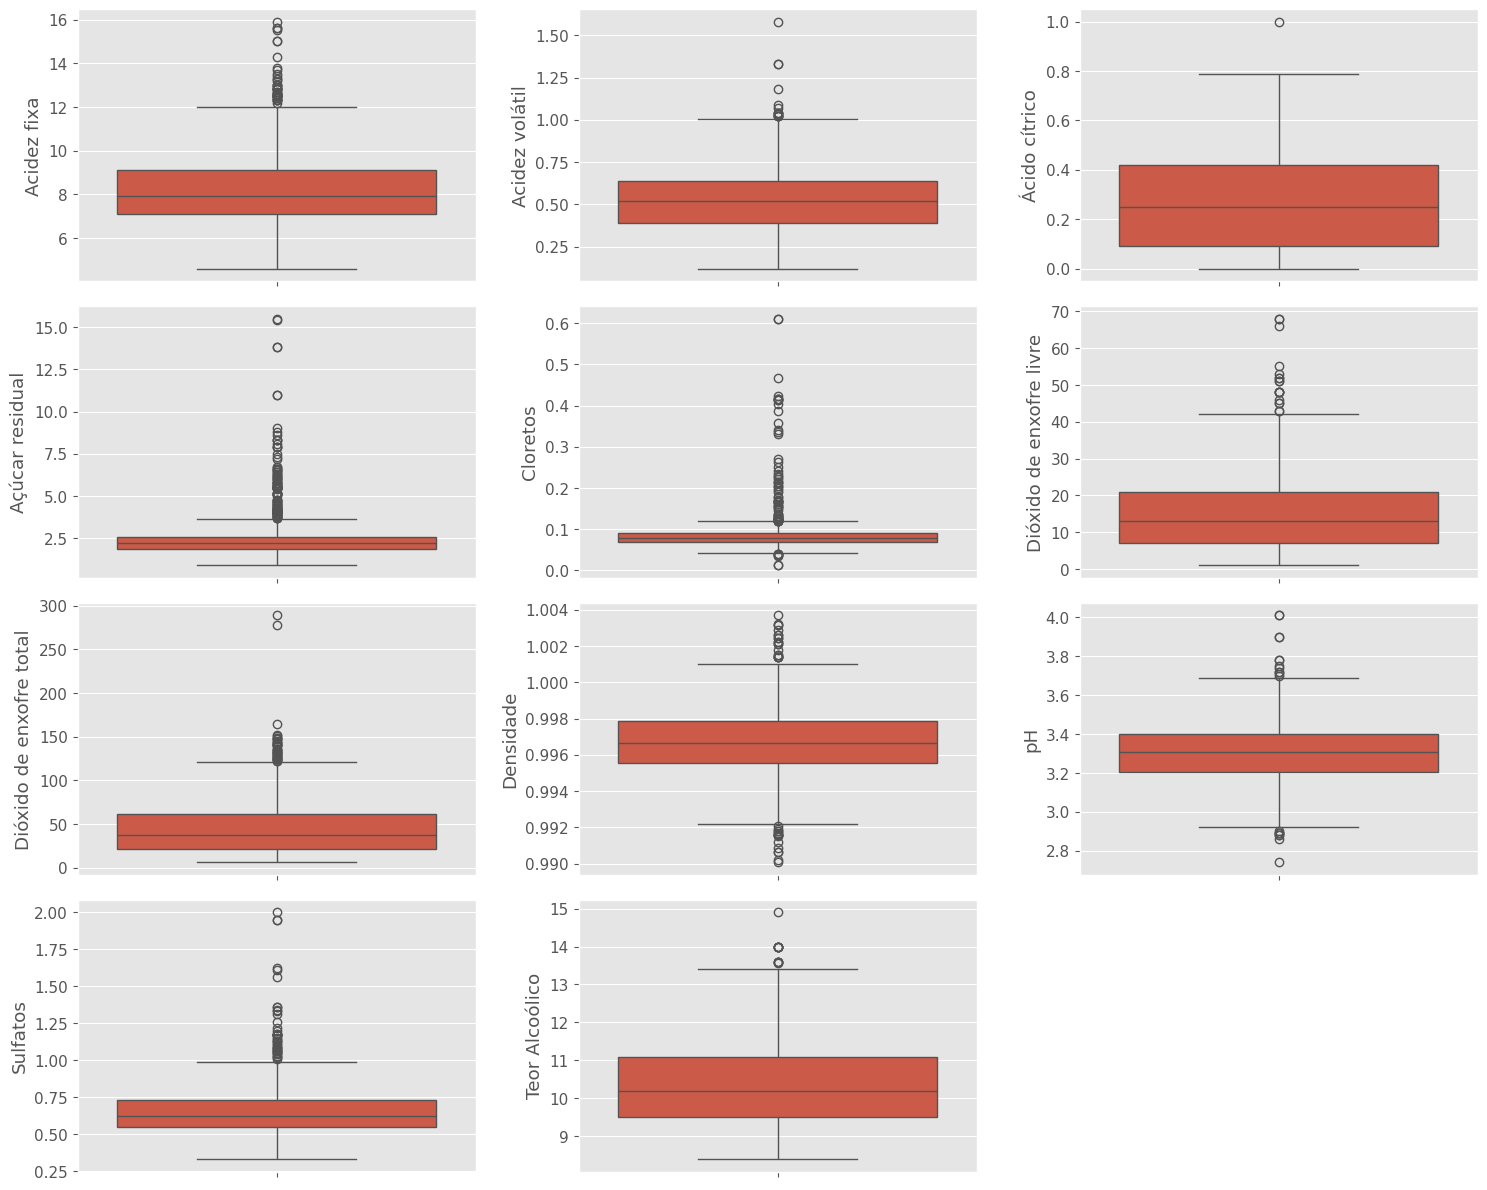

In [239]:
plots.plot_boxplot(df)

### Matriz de Correlação

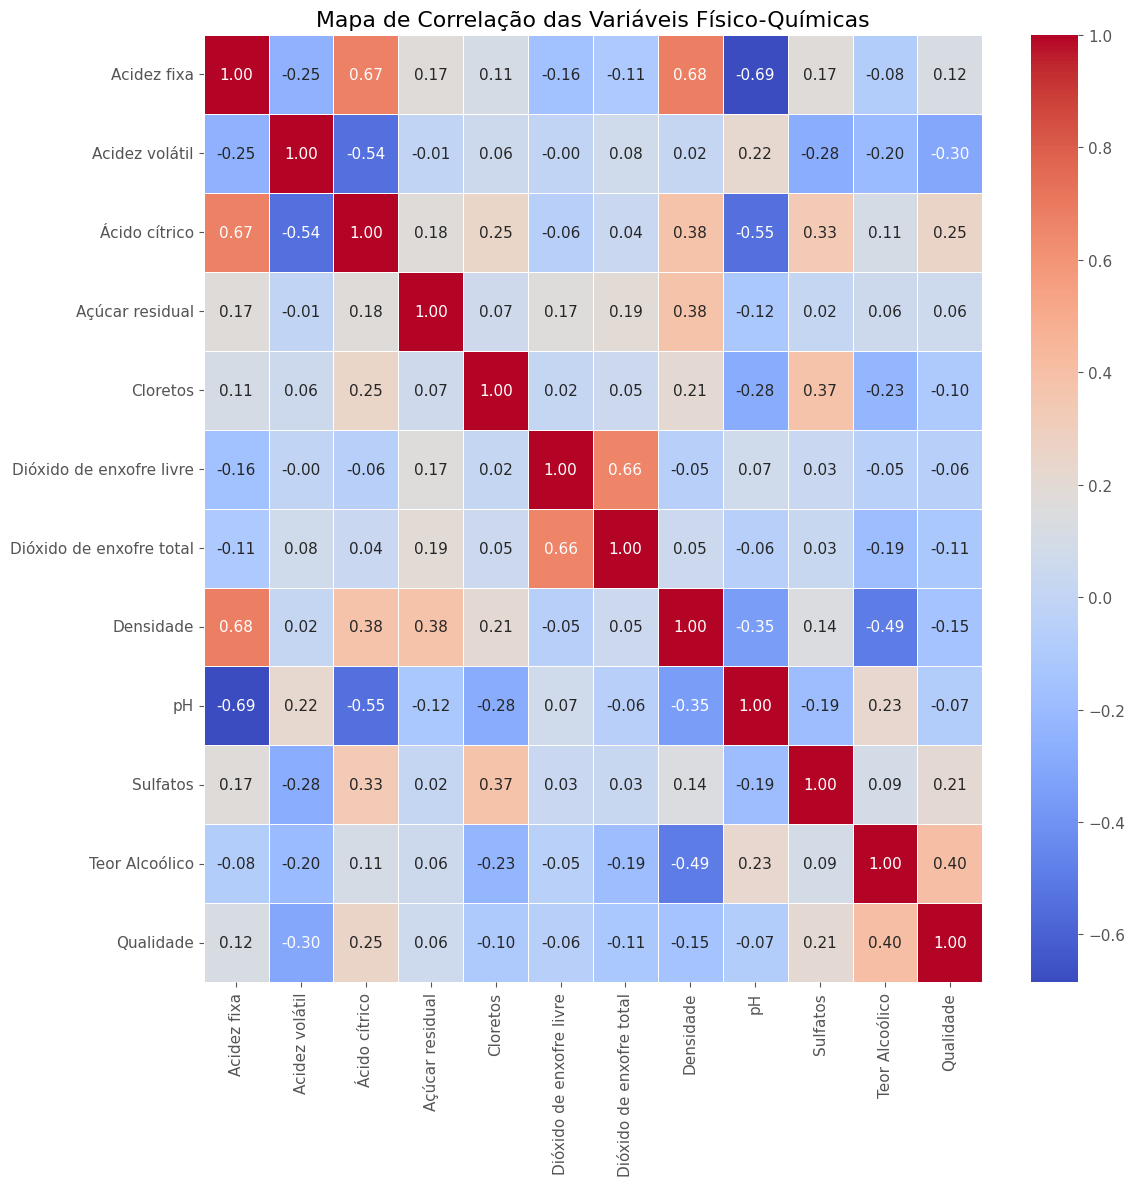

In [240]:
plots.plot_heatmap(df, x_size=12, y_size=12, title="Mapa de Correlação das Variáveis Físico-Químicas")

### Correlação apenas com a qualidade

In [241]:
corr_quality = (
    df.corr()["Qualidade"]
    .drop("Qualidade")
    .sort_values(ascending=False)
)

corr_quality

Teor Alcoólico              0.403676
Ácido cítrico               0.251146
Sulfatos                    0.208020
Acidez fixa                 0.123212
Açúcar residual             0.064145
Dióxido de enxofre livre   -0.055977
pH                         -0.073318
Cloretos                   -0.103985
Dióxido de enxofre total   -0.113373
Densidade                  -0.148670
Acidez volátil             -0.304523
Name: Qualidade, dtype: float64

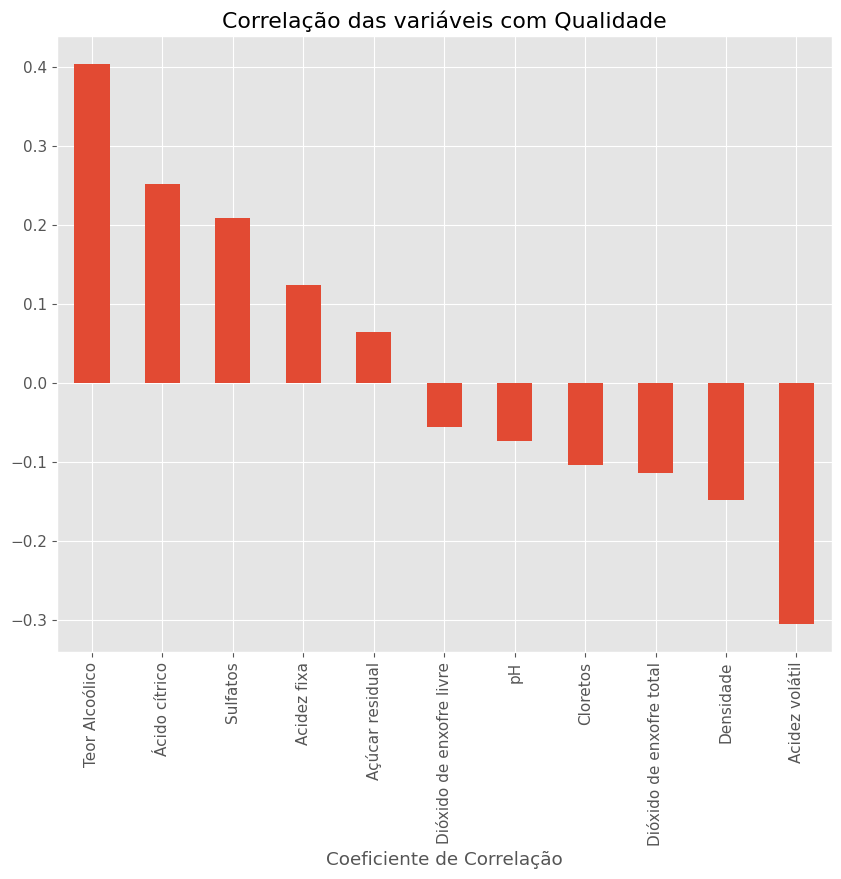

In [242]:
plots.plot_graph(corr_quality, x_size=10, y_size=8, kind="bar", title="Correlação das variáveis com Qualidade", x_label="Coeficiente de Correlação")

### Pairplots

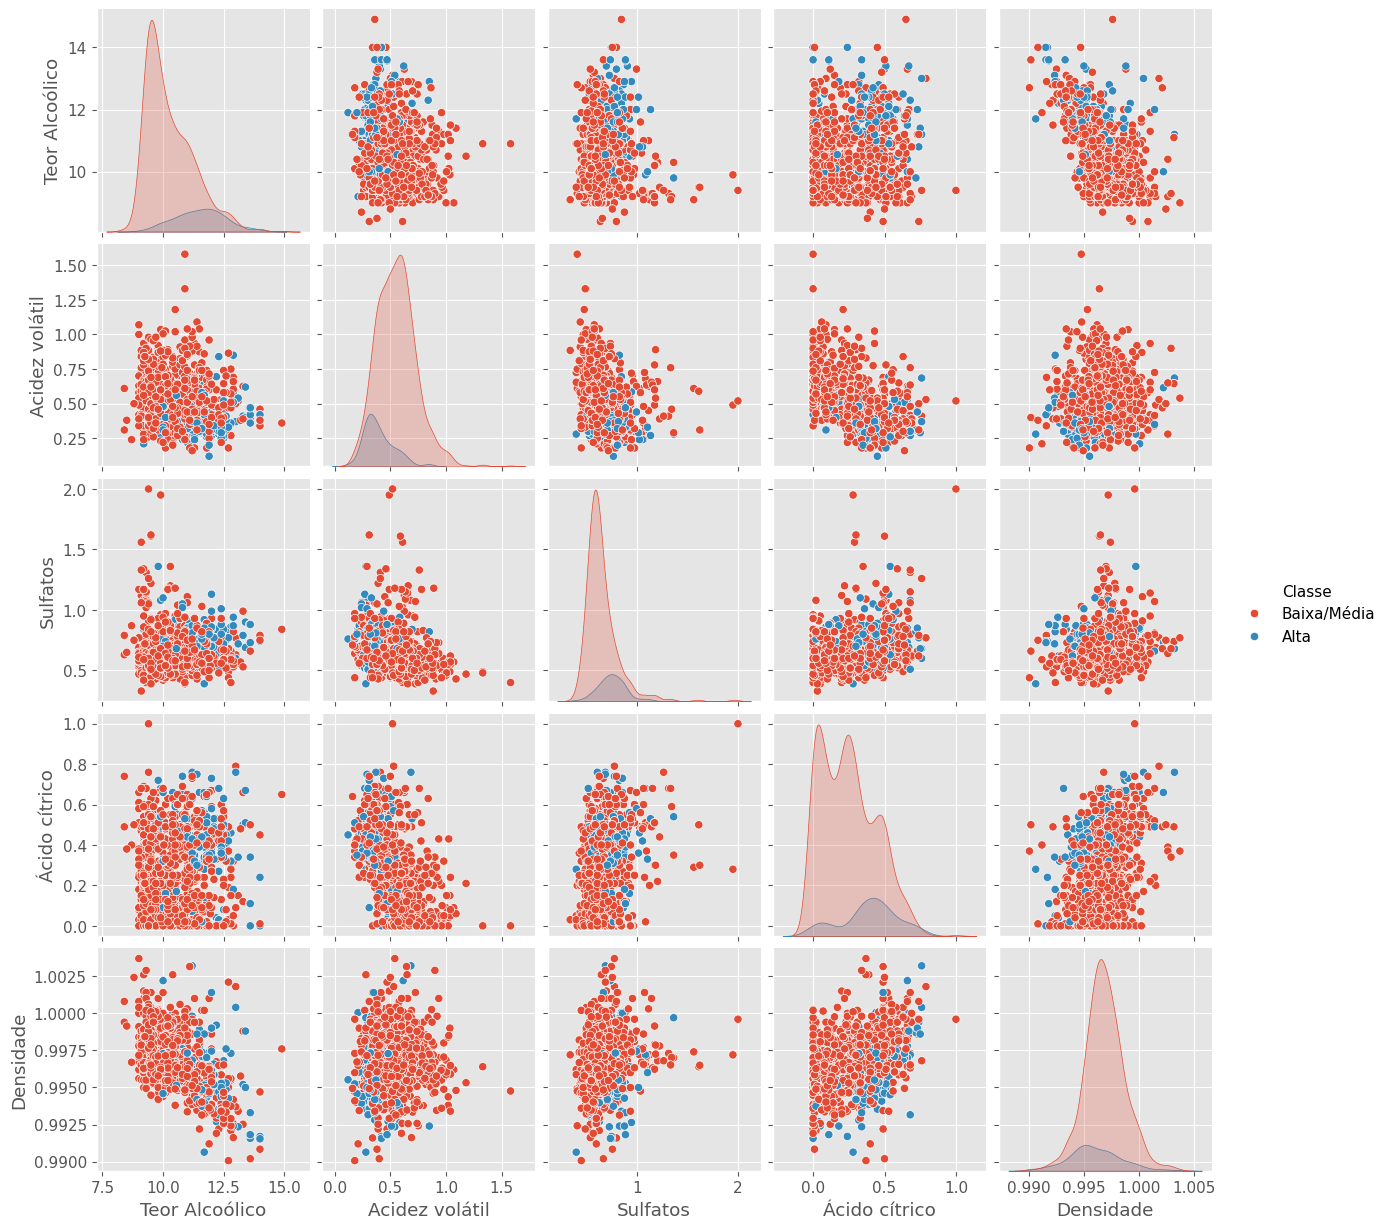

In [243]:
df_plot = df.copy()

df_plot["Classe"] = df_plot["Qualidade"].map({
    0: "Baixa/Média",
    1: "Alta"
})

plots.plot_pairplots(df_plot, columns=["Teor Alcoólico", "Acidez volátil", "Sulfatos", "Ácido cítrico", "Densidade"], hue="Classe")

### Matriz de Correlação Absoluta

In [244]:
corr = (
    df.corr()["Qualidade"]
      .abs()
      .sort_values(ascending=False)
      .drop("Qualidade")
)

display(corr)

Teor Alcoólico              0.403676
Acidez volátil              0.304523
Ácido cítrico               0.251146
Sulfatos                    0.208020
Densidade                   0.148670
Acidez fixa                 0.123212
Dióxido de enxofre total    0.113373
Cloretos                    0.103985
pH                          0.073318
Açúcar residual             0.064145
Dióxido de enxofre livre    0.055977
Name: Qualidade, dtype: float64

## Feature Engineering

### Separação entre Features e Target

In [245]:
X, y = transforms.split_features_target(df, "Qualidade")

### Separação em Treino (80%) e Teste (20%)

In [246]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Padronização

In [247]:
scaler, X_train_scaled, X_test_scaled = transforms.standardize_data(
    X_train,
    X_test
)

### Verificação do balanceamento

In [248]:
print("Treino - variável:", y_train.value_counts(normalize=True))
print("\nTeste - variável:", y_test.value_counts(normalize=True))

Treino - variável: Qualidade
0    0.86105
1    0.13895
Name: proportion, dtype: float64

Teste - variável: Qualidade
0    0.860262
1    0.139738
Name: proportion, dtype: float64


### Padronização

In [249]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelagem

In [250]:
result = pd.DataFrame(columns=[
    "Modelo",
    "Acurácia",
    "Precisão",
    "Recall",
    "F1-score"
])

### KNN

#### Treinamento

In [251]:
knn = ml_models.knn_model(X_train=X_train_scaled, y_train=y_train)

#### Predição

In [252]:
metrics = evaluate.evaluate_model(knn, X_test_scaled, y_test)

result.loc[len(result)] = [
    "KNN",
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1_score"]
]

#### Avaliação

In [253]:
print(f"Acurácia : {metrics['accuracy']:.4f}")
print(f"Precisão : {metrics['precision']:.4f}")
print(f"Recall   : {metrics['recall']:.4f}")
print(f"F1-Score : {metrics['f1_score']:.4f}")

Acurácia : 0.8646
Precisão : 0.8561
Recall   : 0.8646
F1-Score : 0.8597


In [254]:
print(classification_report(y_test, metrics["y_pred"]))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       197
           1       0.52      0.44      0.47        32

    accuracy                           0.86       229
   macro avg       0.71      0.69      0.70       229
weighted avg       0.86      0.86      0.86       229



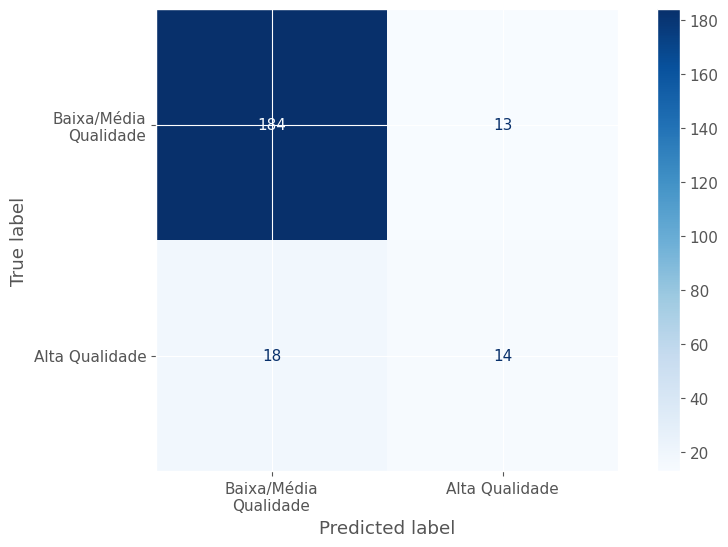

In [255]:
plots.plot_confusion_matrix(y_test, metrics["y_pred"])

### ÁRVORE DE DECISÃO

#### Treinamento

In [256]:
decision_tree = ml_models.decision_tree_model(X_train=X_train_scaled, y_train=y_train)

#### Predição

In [257]:
metrics = evaluate.evaluate_model(decision_tree, X_test_scaled, y_test)

result.loc[len(result)] = [
    "Árvore de Decisão",
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1_score"]
]

#### Avaliação

In [258]:
print(f"Acurácia : {metrics['accuracy']:.4f}")
print(f"Precisão : {metrics['precision']:.4f}")
print(f"Recall   : {metrics['recall']:.4f}")
print(f"F1-Score : {metrics['f1_score']:.4f}")

Acurácia : 0.8690
Precisão : 0.8798
Recall   : 0.8690
F1-Score : 0.8736


In [259]:
print(classification_report(y_test, metrics["y_pred"]))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       197
           1       0.53      0.62      0.57        32

    accuracy                           0.87       229
   macro avg       0.73      0.77      0.75       229
weighted avg       0.88      0.87      0.87       229



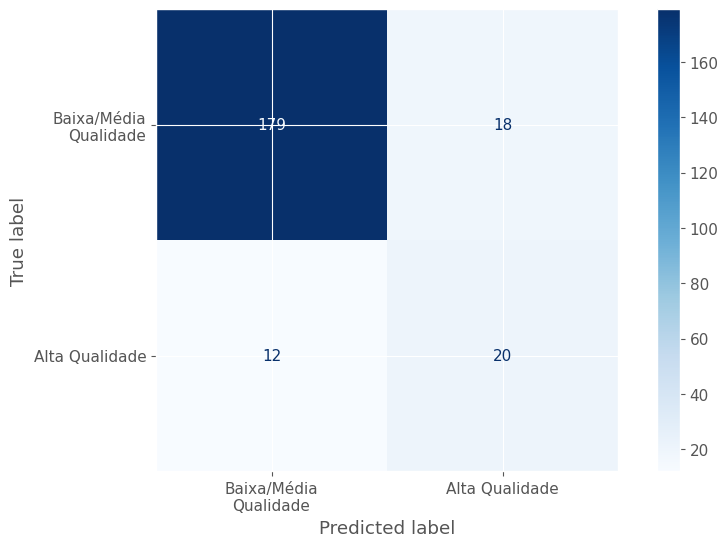

In [260]:
plots.plot_confusion_matrix(y_test, metrics["y_pred"])

### RANDOM FOREST

#### Treinamento

In [261]:
random_forest = ml_models.random_forest_model(X_train=X_train_scaled, y_train=y_train)

#### Predição

In [262]:
metrics = evaluate.evaluate_model(random_forest, X_test_scaled, y_test)

result.loc[len(result)] = [
    "Random Forest",
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1_score"]
]

#### Avaliação

In [263]:
print(f"Acurácia : {metrics['accuracy']:.4f}")
print(f"Precisão : {metrics['precision']:.4f}")
print(f"Recall   : {metrics['recall']:.4f}")
print(f"F1-Score : {metrics['f1_score']:.4f}")

Acurácia : 0.9214
Precisão : 0.9163
Recall   : 0.9214
F1-Score : 0.9166


In [264]:
print(classification_report(y_test, metrics["y_pred"]))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       197
           1       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229



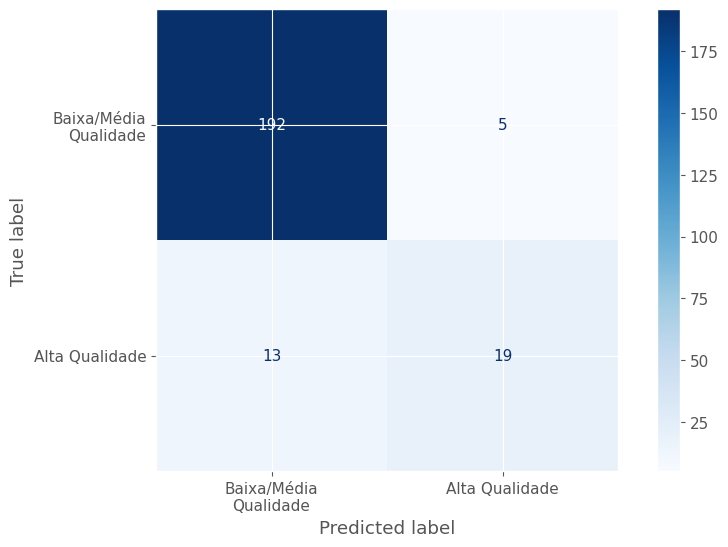

In [265]:
plots.plot_confusion_matrix(y_test, metrics["y_pred"])

### SVM

#### Treinamento

In [266]:
svm = ml_models.svm_model(X_train=X_train_scaled, y_train=y_train)

#### Predição

In [267]:
metrics = evaluate.evaluate_model(decision_tree, X_test_scaled, y_test)

result.loc[len(result)] = [
    "SVM",
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1_score"]
]

#### Avaliação

In [268]:
print(f"Acurácia : {metrics['accuracy']:.4f}")
print(f"Precisão : {metrics['precision']:.4f}")
print(f"Recall   : {metrics['recall']:.4f}")
print(f"F1-Score : {metrics['f1_score']:.4f}")

Acurácia : 0.8690
Precisão : 0.8798
Recall   : 0.8690
F1-Score : 0.8736


In [269]:
print(classification_report(y_test, metrics["y_pred"]))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       197
           1       0.53      0.62      0.57        32

    accuracy                           0.87       229
   macro avg       0.73      0.77      0.75       229
weighted avg       0.88      0.87      0.87       229



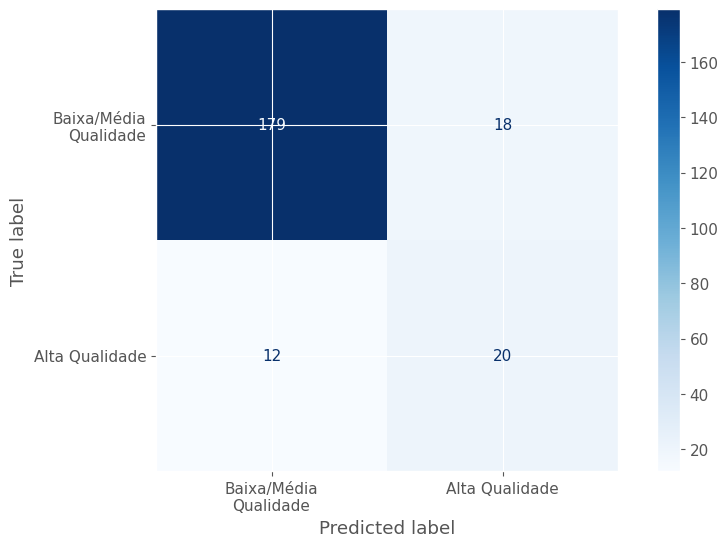

In [270]:
plots.plot_confusion_matrix(y_test, metrics["y_pred"])

### REGRESSÃO LOGÍSTICA

#### Treinamento

In [271]:
logistic_regression = ml_models.logistic_regression_model(X_train=X_train_scaled, y_train=y_train)

#### Predição

In [272]:
metrics = evaluate.evaluate_model(logistic_regression, X_test_scaled, y_test)

result.loc[len(result)] = [
    "Regressão Logística",
    metrics["accuracy"],
    metrics["precision"],
    metrics["recall"],
    metrics["f1_score"]
]

#### Avaliação

In [273]:
print(f"Acurácia : {metrics['accuracy']:.4f}")
print(f"Precisão : {metrics['precision']:.4f}")
print(f"Recall   : {metrics['recall']:.4f}")
print(f"F1-Score : {metrics['f1_score']:.4f}")

Acurácia : 0.7991
Precisão : 0.8630
Recall   : 0.7991
F1-Score : 0.8210


In [274]:
print(classification_report(y_test, metrics["y_pred"]))

              precision    recall  f1-score   support

           0       0.94      0.82      0.88       197
           1       0.38      0.69      0.49        32

    accuracy                           0.80       229
   macro avg       0.66      0.75      0.68       229
weighted avg       0.86      0.80      0.82       229



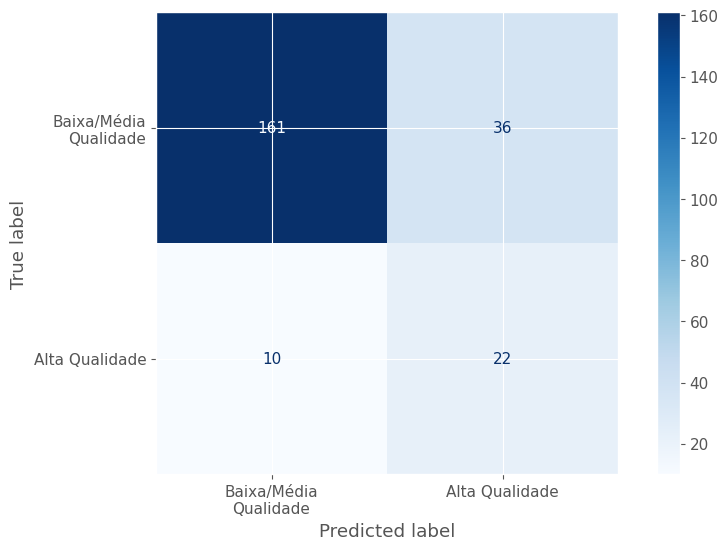

In [275]:
plots.plot_confusion_matrix(y_test, metrics["y_pred"])

### CONSOLIDAÇÃO DOS RESULTADOS

In [276]:
result = result.sort_values(
    by="Acurácia",
    ascending=False
)

result

,Modelo,Acurácia,Precisão,Recall,F1-score
2,Random Forest,0.921397,0.916335,0.921397,0.916565
1,Árvore de Decisão,0.868996,0.879760,0.868996,0.873597
3,SVM,0.868996,0.879760,0.868996,0.873597
0,KNN,0.864629,0.856062,0.864629,0.859741
4,Regressão Logística,0.799127,0.862958,0.799127,0.821046


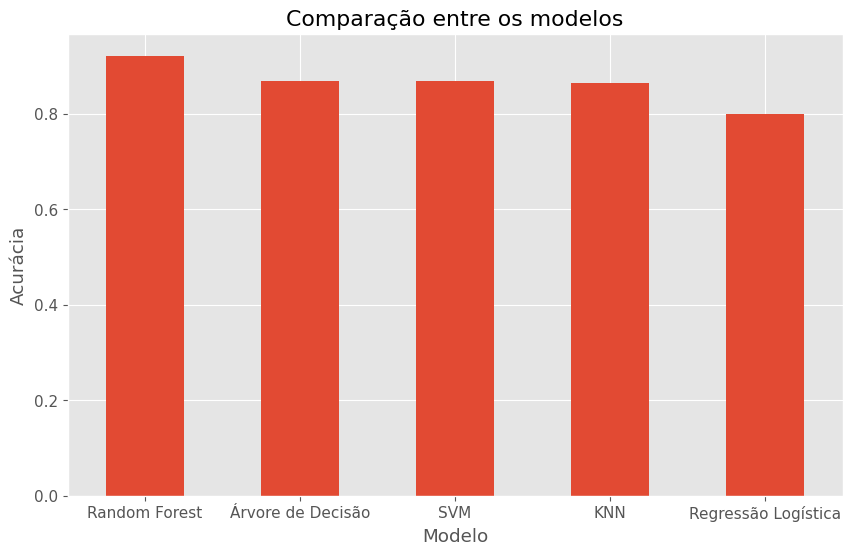

In [277]:
plots.plot_figure(result, x_axis="Modelo", y_axis="Acurácia", kind="bar", title="Comparação entre os modelos", y_label="Acurácia")

## Interpretação dos resultados

In [278]:
importances = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

print(importances)

Dióxido de enxofre livre    0.054535
Cloretos                    0.058821
Açúcar residual             0.062611
pH                          0.068948
Dióxido de enxofre total    0.071572
Acidez fixa                 0.075642
Densidade                   0.096433
Ácido cítrico               0.106958
Acidez volátil              0.115712
Sulfatos                    0.121478
Teor Alcoólico              0.167290
dtype: float64


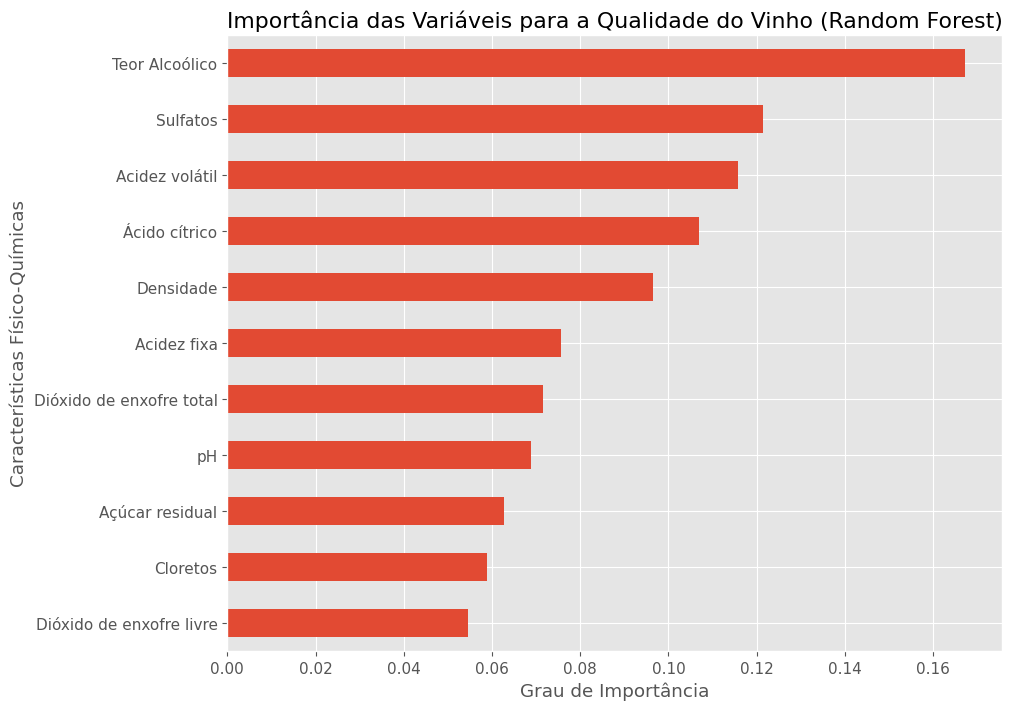

In [279]:
plots.plot_graph(importances, x_size=10, y_size=8, kind="barh", title="Importância das Variáveis para a Qualidade do Vinho (Random Forest)", x_label="Grau de Importância", y_label="Características Físico-Químicas")

A análise demonstrou que o algoritmo Random Forest apresentou o melhor desempenho entre os modelos avaliados, alcançando uma acurácia de 92,14%. Além do desempenho superior, o modelo permitiu identificar quais características físico-químicas exercem maior influência sobre a qualidade dos vinhos.

Os resultados indicam que as variáveis mais relevantes foram:

- Álcool
- Sulfatos
- Ácidez Volátil
- Ácido Cítrico
- Density

Essas informações podem auxiliar produtores e enólogos na priorização do controle das etapas do processo produtivo.


**Controle da fermentação**

O teor de álcool foi a variável mais importante para a classificação da qualidade dos vinhos.

Como o álcool é produzido durante a fermentação dos açúcares pelas leveduras, esse resultado sugere que o controle dessa etapa exerce influência significativa sobre a qualidade final do produto.

Na prática, fatores como:

- temperatura de fermentação;
- escolha da levedura;
- tempo de fermentação;
- teor inicial de açúcar da uva;

podem impactar diretamente a qualidade percebida do vinho.


**Controle microbiológico**

Os sulfatos e o dióxido de enxofre total aparecem entre as variáveis mais importantes.

Esses compostos estão relacionados à estabilidade microbiológica e à conservação do vinho, reduzindo a oxidação e o crescimento de microrganismos indesejáveis.

Esse resultado indica que o correto controle da adição desses compostos pode contribuir para manter as características sensoriais do produto ao longo do armazenamento.


**Redução da acidez volátil**

A acidez volátil aparece como a terceira variável mais importante.

Esse parâmetro normalmente está associado à presença de ácido acético, que em concentrações elevadas pode provocar aromas desagradáveis, semelhantes ao vinagre.

Dessa forma, controlar contaminações bacterianas e garantir boas condições durante a fermentação pode contribuir para a obtenção de vinhos de maior qualidade.


**Controle da densidade**

A densidade também apresentou elevada importância.

Essa variável está diretamente relacionada ao equilíbrio entre álcool e açúcares dissolvidos, sendo frequentemente utilizada para acompanhar a evolução da fermentação.

Seu destaque confirma que o monitoramento da fermentação é uma etapa crítica do processo produtivo.


**Variáveis de menor impacto**

Por outro lado, características como:

- açúcar residual;
- dióxido de enxofre livre;
- pH

apresentaram menor contribuição individual para o modelo.

Isso não significa que sejam irrelevantes para a produção do vinho, mas indica que, considerando este conjunto de dados, possuem menor poder discriminatório para diferenciar os níveis de qualidade quando comparadas às demais variáveis.


**Considerações finais**

Os resultados obtidos demonstram que técnicas de Machine Learning podem ser utilizadas como ferramenta de apoio ao controle de qualidade na indústria vinícola. A identificação das variáveis mais relevantes permite direcionar esforços para o monitoramento dos fatores que apresentam maior impacto sobre a qualidade final do produto, auxiliando na tomada de decisão durante o processo de fabricação.

Embora o modelo não substitua a avaliação sensorial realizada por especialistas, ele pode atuar como um sistema de apoio à decisão, permitindo identificar precocemente lotes com maior probabilidade de apresentar qualidade inferior. Isso possibilita ações corretivas ainda durante a produção, reduzindo desperdícios, aumentando a padronização e contribuindo para a melhoria contínua do processo produtivo.